# Investigating the estimation of the NGARCH model

In [1]:
%matplotlib inline
import internal_script

import datetime as dt
import numpy as np
import os
import pandas as pd
import pandas_datareader as pdr
import warnings
import yfinance as yf

from dorion_francois.garch import ngarch, plot_parameter_series
from dorion_francois.toolkit import print_versions, subcalendar, tic, toc
#from dorion_francois.yf_utils import check_stock_splits

print_versions() # Versions of the critical dependencies

Python: 3.9.19
Numpy: 1.22.3
Pandas: 2.0.3


In [2]:
if True:
    model_class = ngarch
    method,scaled,fname = 'Nelder-Mead',True,'ngarch_ff_estimation.pkl'
else:
    from dorion_francois.agarch import agarch # Not provided with assignment
    model_class = agarch
    method,scaled,fname = 'Nelder-Mead',True,'agarch_ff_estimation.pkl'    

In [3]:
model = model_class.on_fama_french_mkt()
model.get_pv()

/Users/christian/Dropbox/delta_vega/dv_christian/dorion_francois/garch.py:90: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  model.data = pdr.get_data_famafrench('F-F_Research_Data_Factors_daily', start='1900-01-01')[0]


{'lmbda': 0.03, 'omega': 6e-07, 'alpha': 0.06, 'beta': 0.91, 'gamma': 0.6}

In [4]:
model.past_log_excess_returns(model.estimation_time_t0)

,log_xret
Date,
1926-07-01,0.001000
1926-07-02,0.004490
1926-07-06,0.001699
1926-07-07,0.000900
1926-07-08,0.002098
...,...
2017-12-26,-0.000700
2017-12-27,0.000500
2017-12-28,0.002198


In [5]:
last_date = None # pd.Timestamp('2004-12-01')
filename = os.path.join('data',fname)
if True:
    tic()    
    estimates = model.estimate_sequentially(method, scaled, filename, last_date)
    toc()
else:
    estimates = model.read_estimates(filename)
estimates

Starting from time_t0: 2018-01-02 00:00:00
             x0    pv          lb    ub
lmbda  0.030009  0.03          -1     1
omega  -3.71733 6e-07 9.92063e-09 0.001
alpha -0.996215  0.06           0   0.5
beta   0.817065  0.91         0.5  0.99
gamma  0.423649   0.6        -1.5   1.5


,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
Date,,,,,,,,,,,,,
2018-01-02,0.044496,0.000002,0.091679,0.855744,0.607956,82027.203125,265,0.060579,0.00007,0.99939,-0.68419,5.943562,0.000028


,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
2018-02-01,0.044768,0.000002,0.091305,0.856301,0.606997,82105.054688,101.0,0.077333,0.000155,1.000107,-0.684012,5.937055,0.000044


,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
2018-03-01,0.044603,0.000002,0.092528,0.854714,0.605406,82147.5625,96.0,0.15862,-5.237498e-08,0.999841,-0.684336,5.914997,0.000172


,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
2018-04-02,0.044603,0.000002,0.092528,0.854714,0.605406,82209.0625,87.0,0.207361,-0.000193,0.999969,-0.684077,5.906831,0.000281


...

,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
2024-02-01,0.044441,0.000002,0.097191,0.847816,0.608119,86855.273438,96.0,0.095978,-0.000023,1.000228,-0.685528,5.628887,0.000067


,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
2024-03-01,0.04443,0.000002,0.097172,0.847847,0.608076,86923.046875,95.0,0.079632,0.000156,1.000256,-0.685341,5.623894,0.000047


,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
2024-04-01,0.044451,0.000002,0.097166,0.847854,0.608054,86996.695312,94.0,0.06892,0.000189,1.00016,-0.684964,5.62119,0.000035


Elapsed time: 173.027035 seconds.



,lmbda,omega,alpha,beta,gamma,LL,nfev,erp,z_bar,z_std,z_skew,z_kurt,h_tp1
Date,,,,,,,,,,,,,
2018-01-02,0.044496,0.000002,0.091679,0.855744,0.607956,82027.203125,265,0.060579,0.000070,0.999390,-0.684190,5.943562,0.000028
2018-01-03,0.045023,0.000002,0.091285,0.856216,0.608600,82030.953125,97,0.059402,-0.000406,0.999696,-0.685146,5.953551,0.000026
2018-01-04,0.044537,0.000002,0.091293,0.856198,0.608522,82035.015625,99,0.056569,0.000104,0.999723,-0.684784,5.945518,0.000024
2018-01-05,0.044537,0.000002,0.091293,0.856198,0.608522,82038.562500,95,0.055834,0.000158,0.999738,-0.684797,5.944903,0.000023
2018-01-08,0.044794,0.000002,0.091308,0.856295,0.606996,82042.921875,99,0.054386,-0.000088,0.999974,-0.684941,5.944535,0.000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-24,0.044451,0.000002,0.097166,0.847854,0.608054,87052.109375,103,0.105378,-0.000045,1.000222,-0.684508,5.614737,0.000080
2024-04-25,0.044451,0.000002,0.097166,0.847854,0.608054,87055.742188,96,0.105736,-0.000067,1.000209,-0.684449,5.614803,0.000081
2024-04-26,0.044451,0.000002,0.097166,0.847854,0.608054,87058.921875,95,0.099872,-0.000024,1.000214,-0.684489,5.614484,0.000072


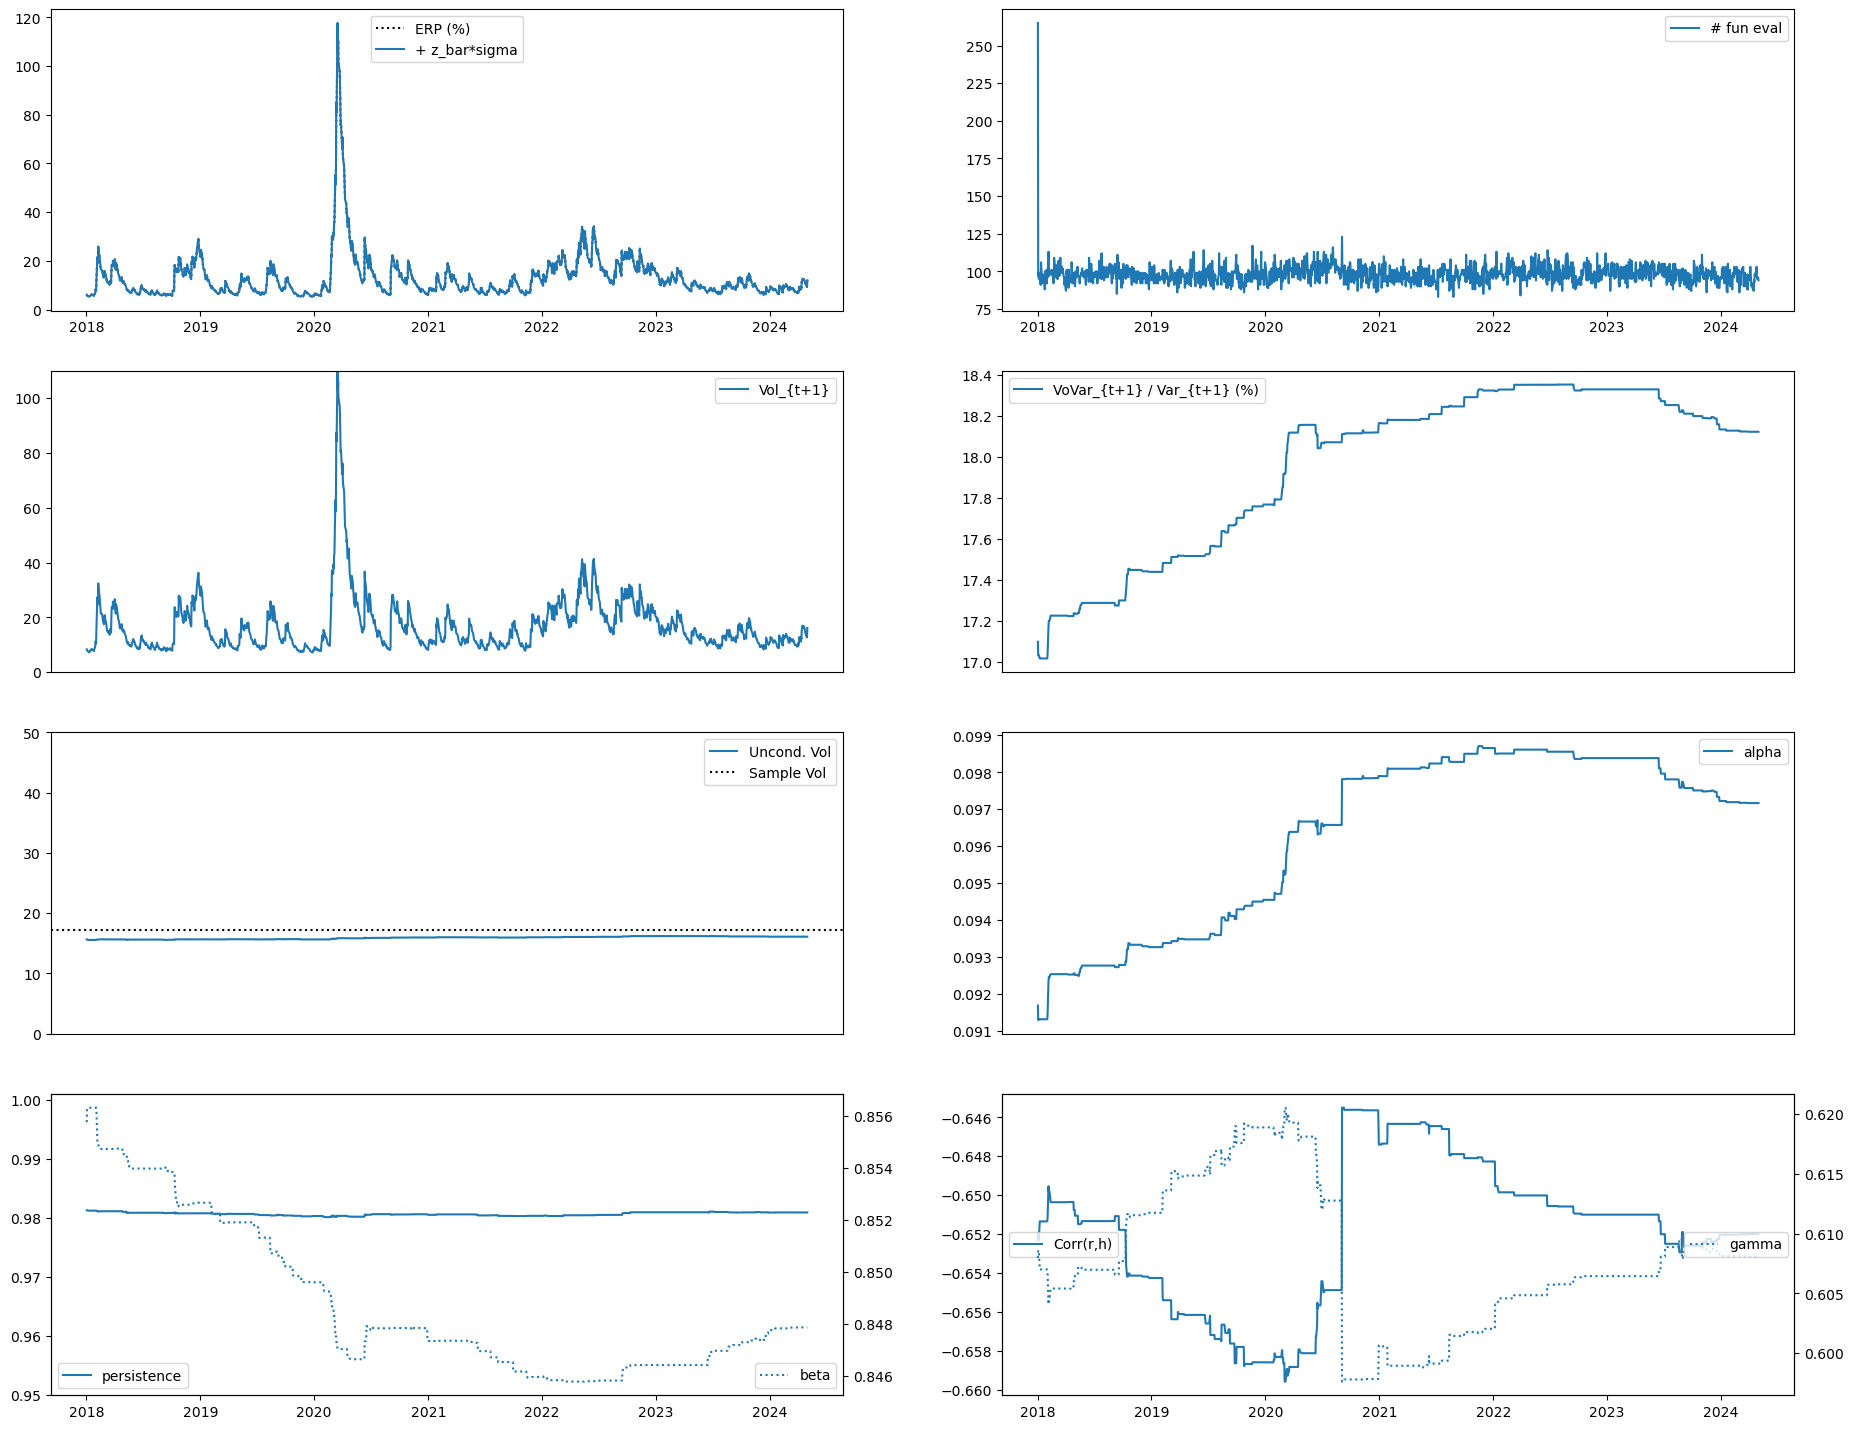

In [6]:
plot_parameter_series(model, estimates);

As illustrated by the above graph, the NGARCH model implies an annualized ERP that can reach very high levels. These are not very long lived, so their annualized value could not be earned over a sustained period. The median level reported below is nonetheless rather high:

In [10]:
(100*estimates[['erp']]).describe()

,erp
count,1592.000000
mean,13.114610
std,10.054048
min,5.203646
25%,7.731927
50%,10.570264
75%,15.445294
max,117.703444


### Comparing likelihoods with those of the NGARCH

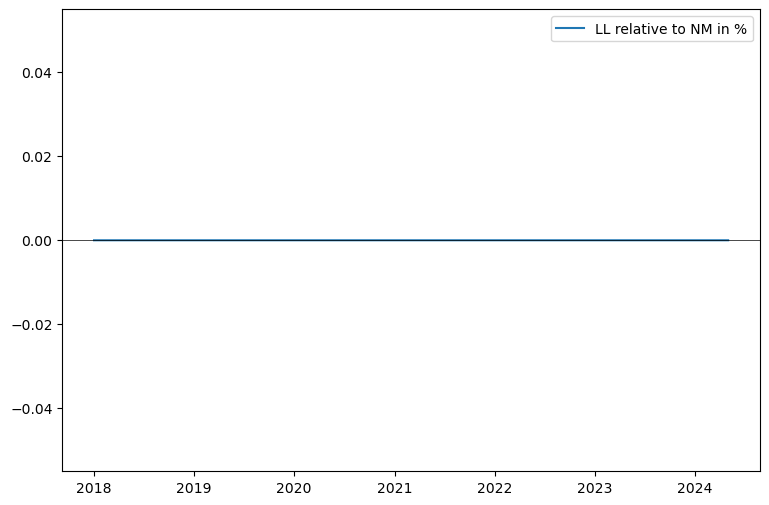

In [7]:
import pickle
import matplotlib.pyplot as plt
nm_fname = f'data/test/garch/test_ngarch.pkl'
nm_filename = os.path.join(".", nm_fname)
with open(nm_filename,'rb') as fh:
    estNM = pickle.load(fh)
    
fig, ax = plt.subplots(1, 1, figsize=(9,6)) #(14,13)
ax.plot(100*(estimates.LL/estNM.LL - 1), label='LL relative to NM in %')
ax.axhline(0,color='k', linewidth=0.5)
ylim = ax.get_ylim()
if ylim[1]-ylim[0] < 0.0020: # +/- 10bps
    ax.set_ylim(-0.0010, 0.0010) # +/- 10bps
ax.legend(loc = 'upper right');